# 🐧 Palmer Penguins: Morphological Analysis & Species Prediction

## Project Overview

This project explores the famous **Palmer Penguins dataset** to understand how penguin species differ in terms of morphology, habitat distribution, and sex-based characteristics.

The main goal is to identify the strongest numerical and categorical patterns that separate the three species:

- Adelie
- Chinstrap
- Gentoo

Beyond exploratory data analysis, this project also aims to build a simple machine learning classification model capable of predicting a penguin’s species based on its physical characteristics.

---

## Objectives

This notebook aims to answer the following questions:

1. How are penguin species distributed across different islands?
2. Which physical measurements best distinguish each species?
3. Are there meaningful differences between male and female penguins?
4. What numerical features are most strongly correlated?
5. Can we predict whether a penguin is an **Adelie**, **Chinstrap**, or **Gentoo** based on its measurements?

---

## Final Goal

By the end of this analysis, the notebook will combine:

- Exploratory Data Analysis;
- Statistical interpretation;
- Visual storytelling;
- Feature relationship analysis;
- A species classification model.

The final model should allow us to estimate a penguin species from inputs such as:

- culmen length;
- culmen depth;
- flipper length;
- body mass;
- sex;
- island.

In [2]:
# Importing the libraries:

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

# 📊 Data Understanding

Before starting the analysis, it is important to understand the dataset structure, variable types, and overall data quality.

This section explores:

- dataset dimensions;
- numerical and categorical features;
- missing values;
- invalid or inconsistent entries;
- basic statistical summaries.

Understanding the dataset structure helps guide the cleaning process and supports more reliable exploratory and statistical analysis throughout the project.

In [3]:
# Global variables to use in the notebook

categorical_col = ['species', 'island', 'sex']
numerical_col = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
palette = ["#EF476F", "#FFD166", "#06D6A0", "#118AB2", "#073B4C"]
# palette = https://coolors.co/palette/ef476f-ffd166-06d6a0-118ab2-073b4c

In [4]:
df = pd.read_csv("./data/penguins_size.csv")
df.head(5)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
print(f"The dimensions of the dataset are{df.shape[0]} lines and {df.shape[1]} variables")

# Checking the numeric values of the dataset
display(df.describe())

# Checking the data type and nulls of the dataset
display(df.info())

The dimensions of the dataset are344 lines and 7 variables


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


None

In [6]:
# Checking evert NaN values in the dataset
df.isna().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [7]:
# Two penguins have NaN values for all numeric (and sex) variables.
# Eight of them have only the sex null.
# And one of them have the sex as a string = "."
# On the cleaning section, I will explain what to do with them.

display(print(df[~df["sex"].isin(["FEMALE", "MALE"])]))

    species     island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
3    Adelie  Torgersen               NaN              NaN                NaN   
8    Adelie  Torgersen              34.1             18.1              193.0   
9    Adelie  Torgersen              42.0             20.2              190.0   
10   Adelie  Torgersen              37.8             17.1              186.0   
11   Adelie  Torgersen              37.8             17.3              180.0   
47   Adelie      Dream              37.5             18.9              179.0   
246  Gentoo     Biscoe              44.5             14.3              216.0   
286  Gentoo     Biscoe              46.2             14.4              214.0   
324  Gentoo     Biscoe              47.3             13.8              216.0   
336  Gentoo     Biscoe              44.5             15.7              217.0   
339  Gentoo     Biscoe               NaN              NaN                NaN   

     body_mass_g  sex  
3            Na

None

# 🧹 Data Cleaning

Raw datasets often contain missing values, inconsistent information, or invalid entries that can negatively affect the analysis. This one is no different.

This section focuses on identifying and handling data quality issues to ensure the dataset is reliable, consistent, and ready for exploratory analysis and machine learning applications.

In this case, we will clean the rows that have NaN or "." values for the penguin's sex.
Since these occurrences represent less than 5% of the dataset and could negatively affect statistical analysis and model performance, the affected rows were removed instead of being imputed.

In [8]:
# Creating a new dataframe with cleaner values

clean_df = df[
    df["sex"].notna() &
    (df["sex"] != ".")
].copy()

if clean_df.isna().sum().sum() == 0:
    print("Inconsistences removed")
else:
    print("There are still inconsistent")
clean_df

Inconsistences removed


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


# 🔍 Exploratory Data Analysis (EDA) and Data Visualization

Exploratory Data Analysis is used to investigate patterns, relationships, and behaviors within the dataset.

This section explores both numerical and categorical variables through statistical summaries and visual analysis, helping identify trends, distributions, correlations, and species-specific characteristics, the next cells will also display charts and graphical analysis to better understand penguin distributions, feature relationships, species separation, and potential behavioral patterns within the dataset.

In [9]:
# General frequency analysis for categorical variables

for col in categorical_col:
    print(clean_df[col].value_counts())
    print("-" * 40)

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64
----------------------------------------
island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64
----------------------------------------
sex
MALE      168
FEMALE    165
Name: count, dtype: int64
----------------------------------------


C:\Users\leona\AppData\Local\Temp\ipykernel_23652\59771973.py:13: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.countplot(
C:\Users\leona\AppData\Local\Temp\ipykernel_23652\59771973.py:13: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.countplot(
C:\Users\leona\AppData\Local\Temp\ipykernel_23652\59771973.py:13: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.countplot(


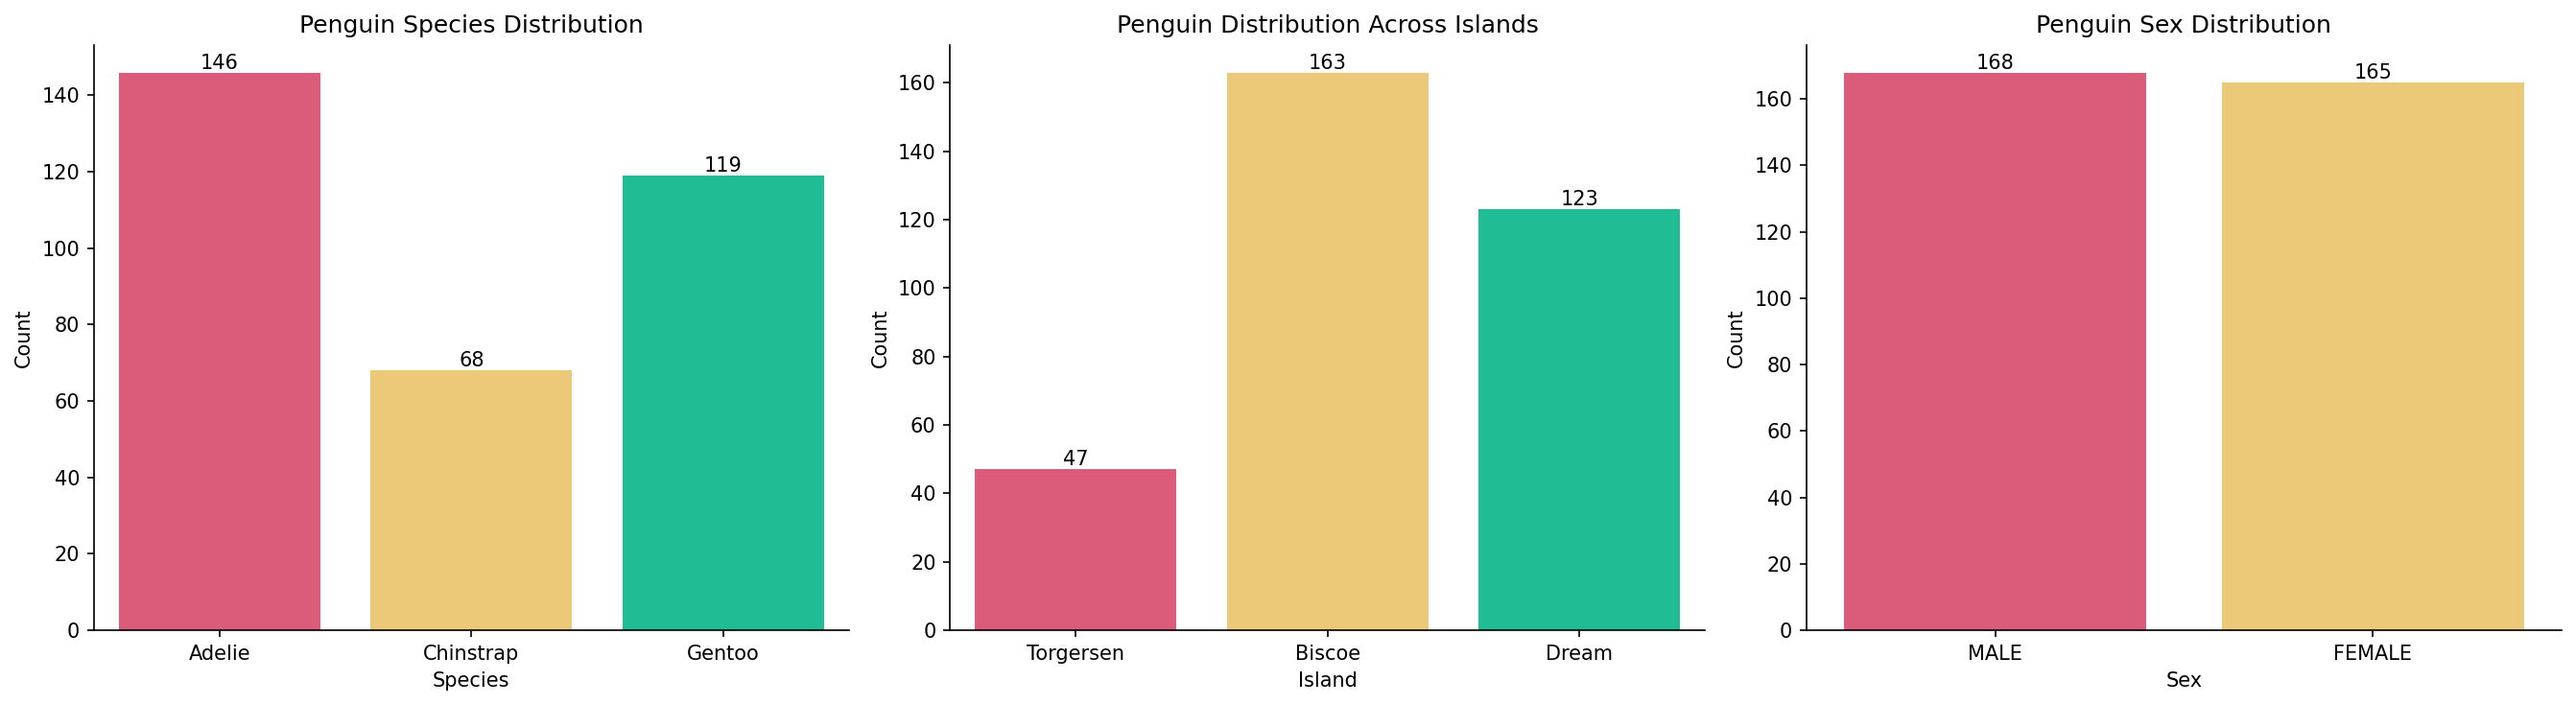

In [ ]:
# Visualizing categorical variables

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

charts = [
    ("species", "Penguin Species Distribution", "Species"),
    ("island", "Penguin Distribution Across Islands", "Island"),
    ("sex", "Penguin Sex Distribution", "Sex")
]

for ax, (col, title, xlabel) in zip(axes, charts):

    sns.countplot(
        data=clean_df,
        x=col,
        hue=col,
        palette=palette,
        legend=False,
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(container)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")

sns.despine()

plt.tight_layout()
plt.show()

In [11]:
# Mean numerical measurements by island and species

clean_df.groupby(["island", "species"])[numerical_col].mean().round(2)

culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
island    species                                                           
Biscoe    Adelie                38.98            18.37             188.80   
          Gentoo                47.57            15.00             217.24   
Dream     Adelie                38.52            18.24             189.93   
          Chinstrap             48.83            18.42             195.82   
Torgersen Adelie                39.04            18.45             191.53   

                     body_mass_g  
island    species                 
Biscoe    Adelie         3709.66  
          Gentoo         5092.44  
Dream     Adelie         3701.36  
          Chinstrap      3733.09  
Torgersen Adelie         3708.51

C:\Users\leona\AppData\Local\Temp\ipykernel_23652\61701797.py:4: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  ax = sns.countplot(


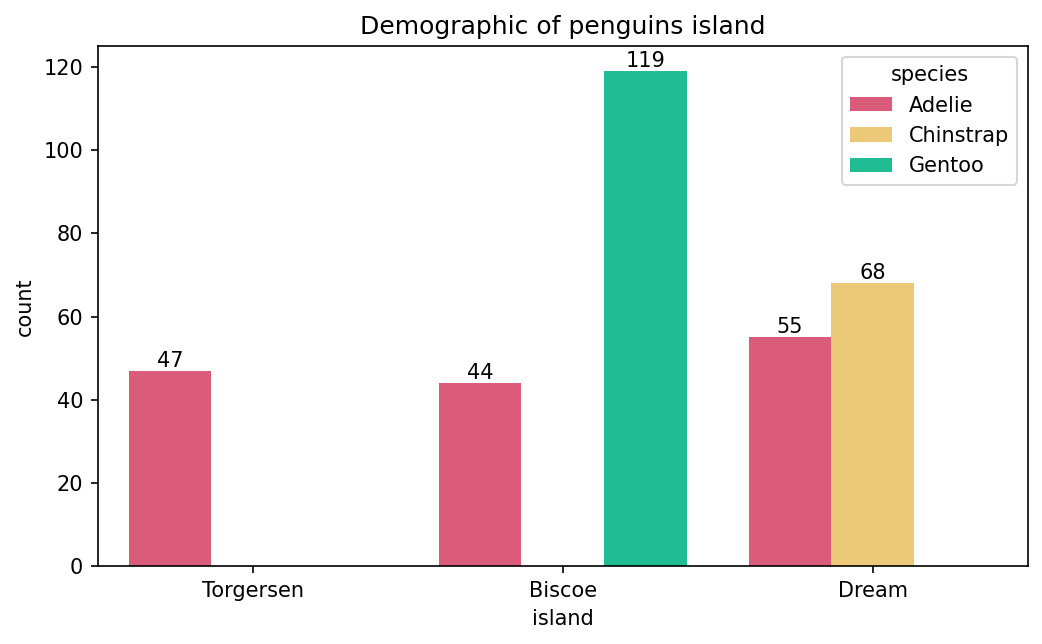

In [12]:
# Visualizing the data
plt.figure(figsize=(8, 4.5), dpi=150)

ax = sns.countplot(
    data=clean_df,
    x="island",
    hue="species",
    palette=palette,
    legend=True
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Demographic of penguins island")
plt.show()

In [13]:
# Checking numerical measurements by sex

clean_df.groupby(["species", "sex"])[numerical_col].mean().round(2)

# We can see that males, in all three species have more body mass, have
# larger culmen length and depth and a larger flipper.

culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
species   sex                                                            
Adelie    FEMALE             37.26            17.62             187.79   
          MALE               40.39            19.07             192.41   
Chinstrap FEMALE             46.57            17.59             191.74   
          MALE               51.09            19.25             199.91   
Gentoo    FEMALE             45.56            14.24             212.71   
          MALE               49.47            15.72             221.54   

                  body_mass_g  
species   sex                  
Adelie    FEMALE      3368.84  
          MALE        4043.49  
Chinstrap FEMALE      3527.21  
          MALE        3938.97  
Gentoo    FEMALE      4679.74  
          MALE        5484.84

C:\Users\leona\AppData\Local\Temp\ipykernel_23652\1235088606.py:5: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.histplot(


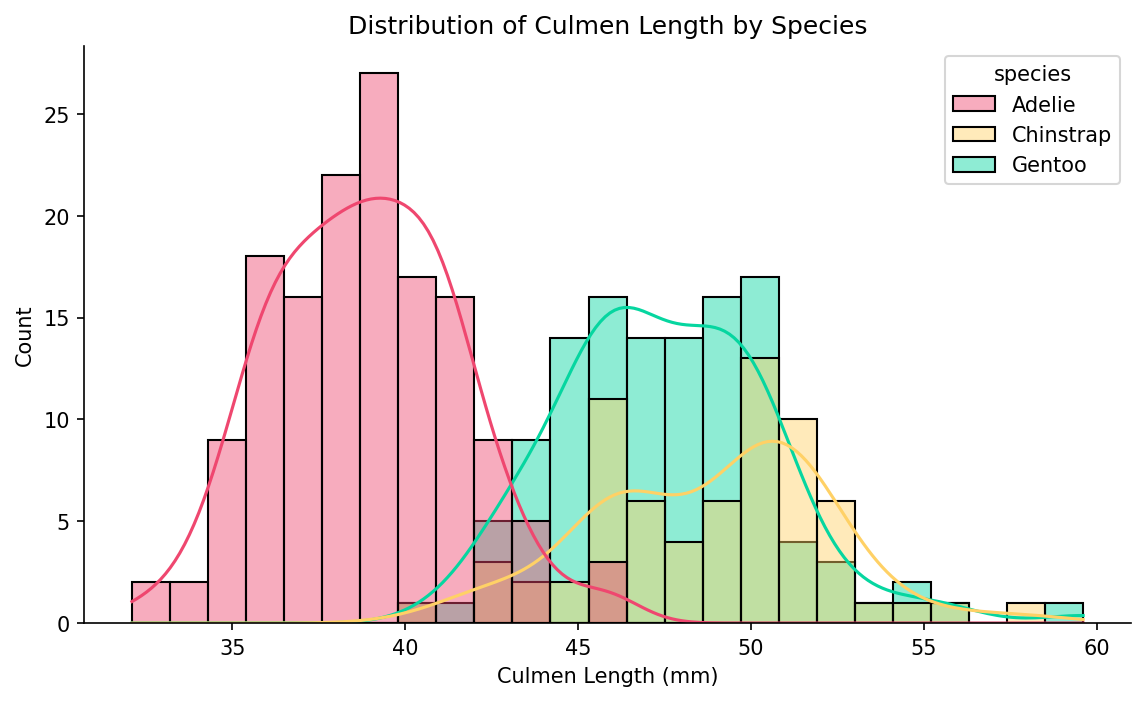

In [29]:
# Distribution of culmen length across penguin species

plt.figure(figsize=(9, 5), dpi=150)

sns.histplot(
    data=clean_df,
    x="culmen_length_mm",
    hue="species",
    kde=True,
    bins=25,
    palette=palette,
    alpha=0.45
)

plt.title("Distribution of Culmen Length by Species")
plt.xlabel("Culmen Length (mm)")
plt.ylabel("Count")

sns.despine()

plt.show()

# Checking for outliers

C:\Users\leona\AppData\Local\Temp\ipykernel_23652\2717758942.py:17: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#EF476F'` for the same effect.

  sns.boxplot(
C:\Users\leona\AppData\Local\Temp\ipykernel_23652\2717758942.py:17: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#FFD166'` for the same effect.

  sns.boxplot(
C:\Users\leona\AppData\Local\Temp\ipykernel_23652\2717758942.py:17: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#06D6A0'` for the same effect.

  sns.boxplot(
C:\Users\leona\AppData\Local\Temp\ipykernel_23652\2717758942.py:17: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#118AB2'` for the same effect.

  sns.boxplot(


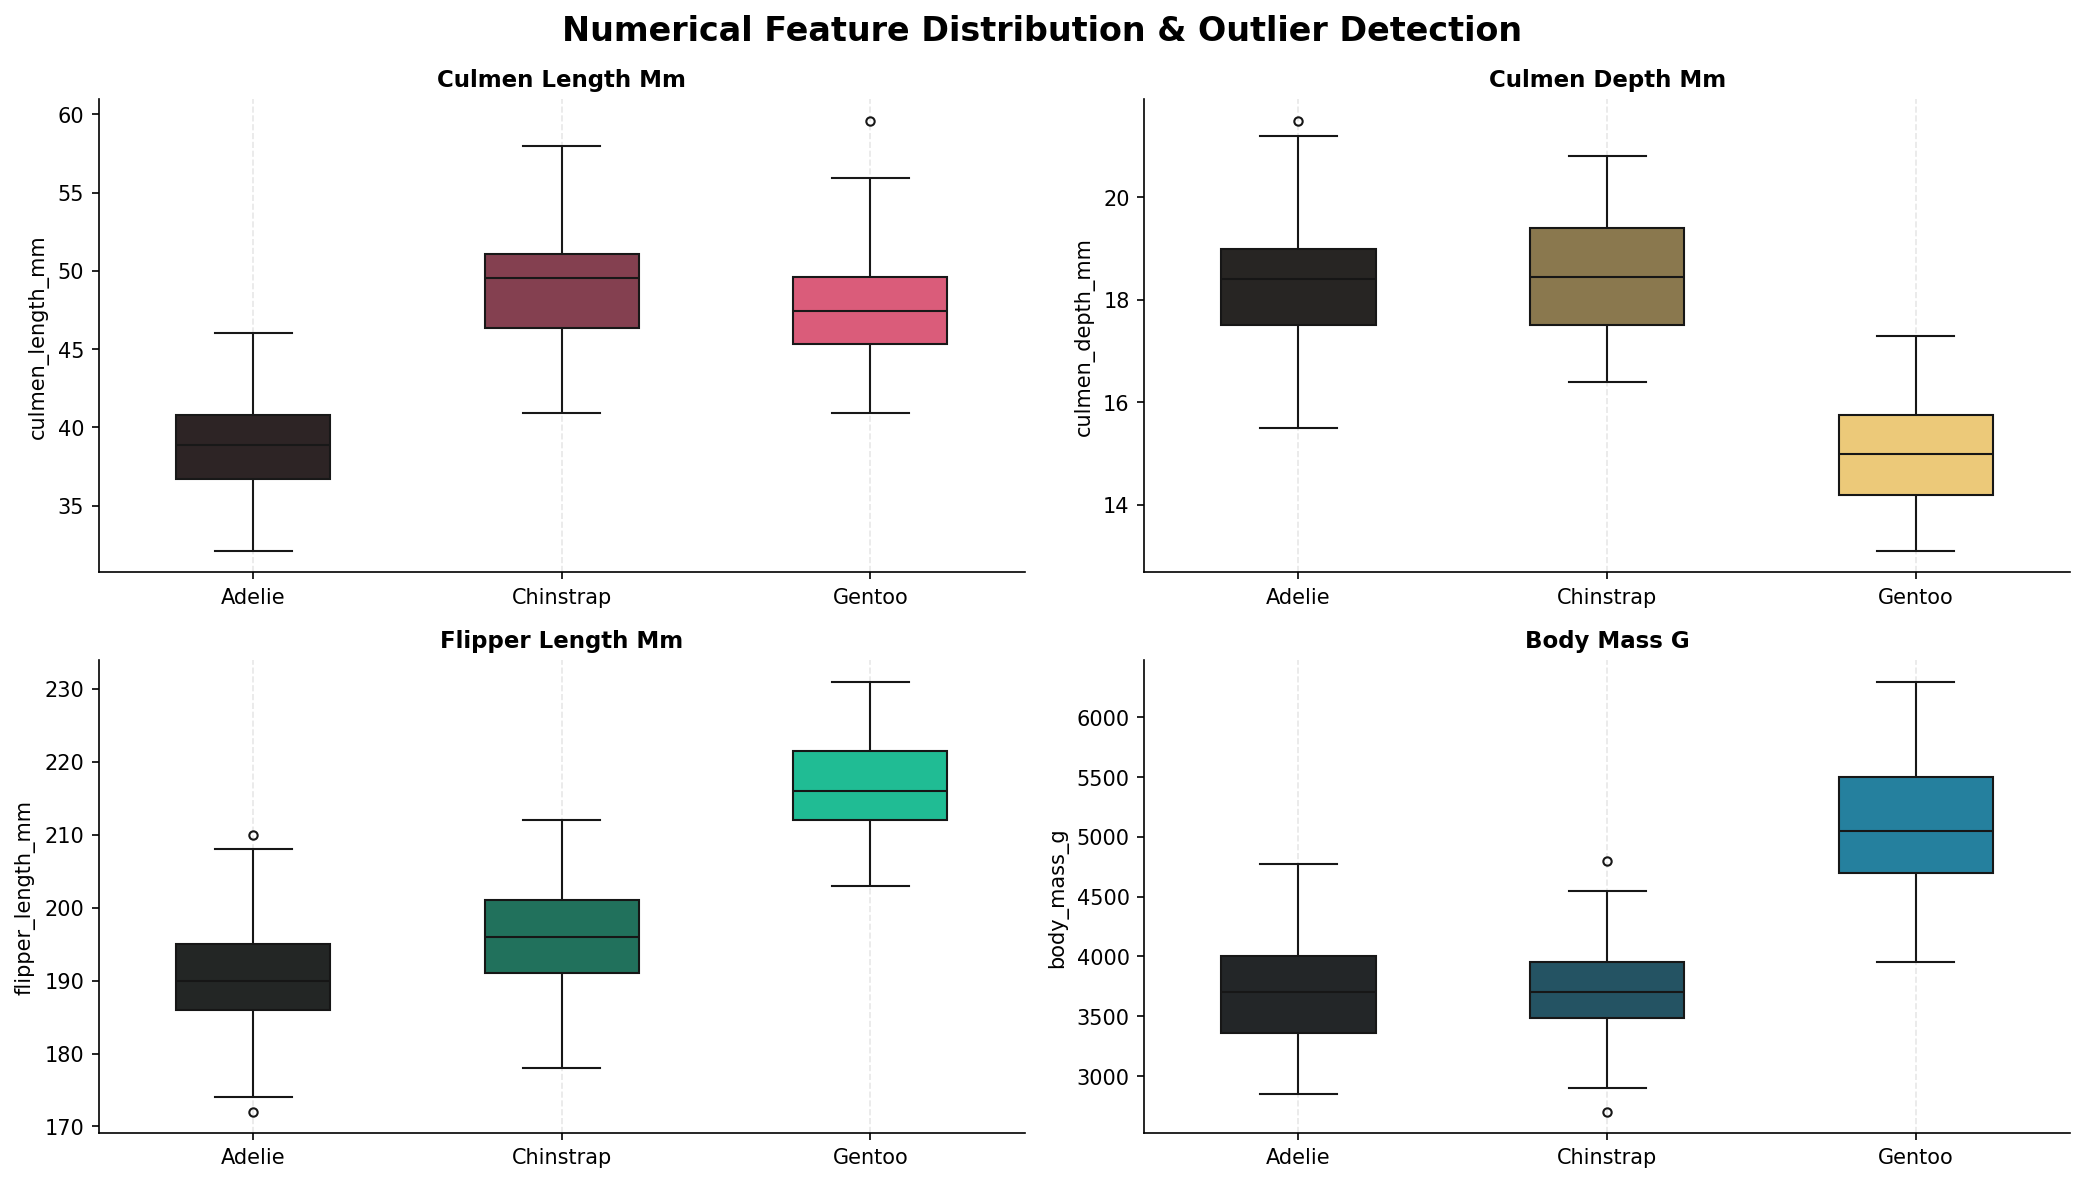

In [35]:
# Investigating numerical distributions and potential outliers

n_cols = len(numerical_col)
n_rows = (n_cols + 1) // 2

fig, axes = plt.subplots(
    n_rows,
    2,
    figsize=(14, 4 * n_rows),
    dpi=150
)

axes = axes.flatten()

for i, col in enumerate(numerical_col):

    sns.boxplot(
        data=clean_df,
        x="species",
        y=col,
        hue="species",
        ax=axes[i],
        color=palette[i],
        width=0.5,
        fliersize=4
    )

    axes[i].set_title(
        col.replace("_", " ").title(),
        fontsize=11,
        fontweight="bold"
    )

    axes[i].set_xlabel("")
    axes[i].grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

for j in range(n_cols, len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "Numerical Feature Distribution & Outlier Detection",
    fontsize=16,
    fontweight="bold"
)

sns.despine()

plt.tight_layout()

plt.show()

In [18]:
for col in numerical_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

culmen_length_mm: 0 outliers
culmen_depth_mm: 0 outliers
flipper_length_mm: 0 outliers
body_mass_g: 0 outliers


# 📐 Statistical Analysis

Statistical analysis helps validate patterns observed during exploratory analysis and provides a deeper understanding of feature relationships.

This section investigates correlations, group differences, and numerical behaviors across penguin species to support more reliable interpretations.

In [19]:

for penguin_species in df['species'].dropna().unique():
    df_species = df[df['species'] == penguin_species].copy()
    print(f'Penguin species:{penguin_species}')
    print(df_species[numerical_col].corr().round(4))
    print('--------------------------------------------')

Penguin species:Adelie
                   culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
culmen_length_mm             1.0000           0.3915             0.3258   
culmen_depth_mm              0.3915           1.0000             0.3076   
flipper_length_mm            0.3258           0.3076             1.0000   
body_mass_g                  0.5489           0.5761             0.4682   

                   body_mass_g  
culmen_length_mm        0.5489  
culmen_depth_mm         0.5761  
flipper_length_mm       0.4682  
body_mass_g             1.0000  
--------------------------------------------
Penguin species:Chinstrap
                   culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
culmen_length_mm             1.0000           0.6535             0.4716   
culmen_depth_mm              0.6535           1.0000             0.5801   
flipper_length_mm            0.4716           0.5801             1.0000   
body_mass_g                  0.5136           0.6045             

In [20]:
df.groupby("species")[
    ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
].mean()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.791391,18.346358,189.953642,3700.662252
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.504878,14.982114,217.186992,5076.016260


C:\Users\leona\AppData\Local\Temp\ipykernel_23652\3439330783.py:11: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(


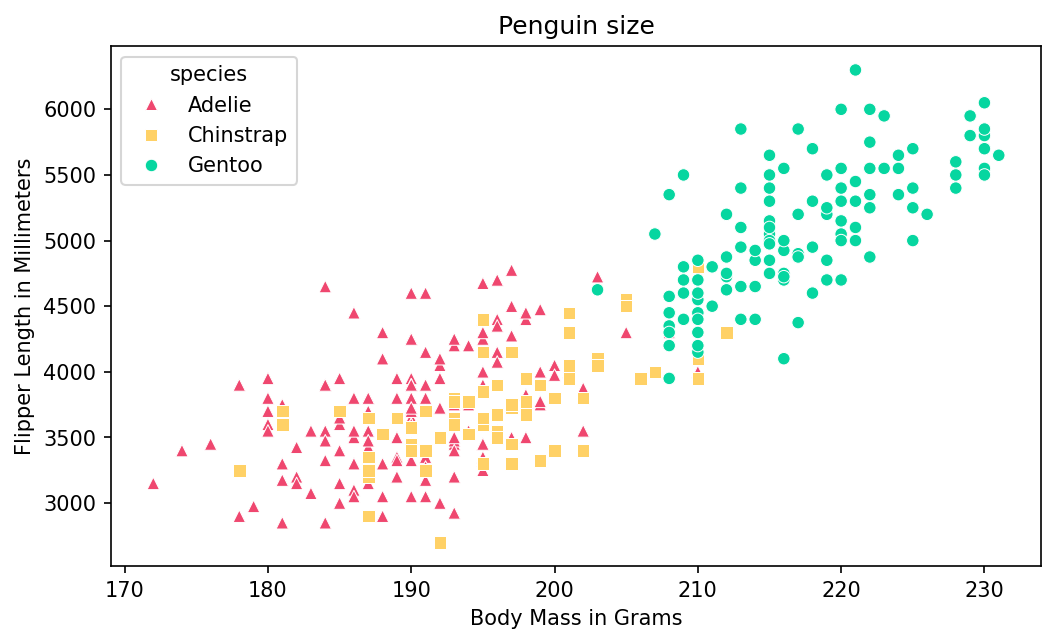

In [21]:
# Ploting a chart that displays penguins "size" grouping by penguins species

plt.figure(figsize=(8, 4.5), dpi=150)

markers = {
    "Adelie": "^",
    "Chinstrap": "s",
    "Gentoo": "o"
}

sns.scatterplot(
    data=df,
    y="body_mass_g",
    x="flipper_length_mm",
    hue="species",
    style="species",
    markers=markers,
    palette=palette
)

plt.title("Penguin size")
plt.xlabel("Body Mass in Grams")
plt.ylabel("Flipper Length in Millimeters")
plt.show()

C:\Users\leona\AppData\Local\Temp\ipykernel_23652\662952521.py:12: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.scatterplot(


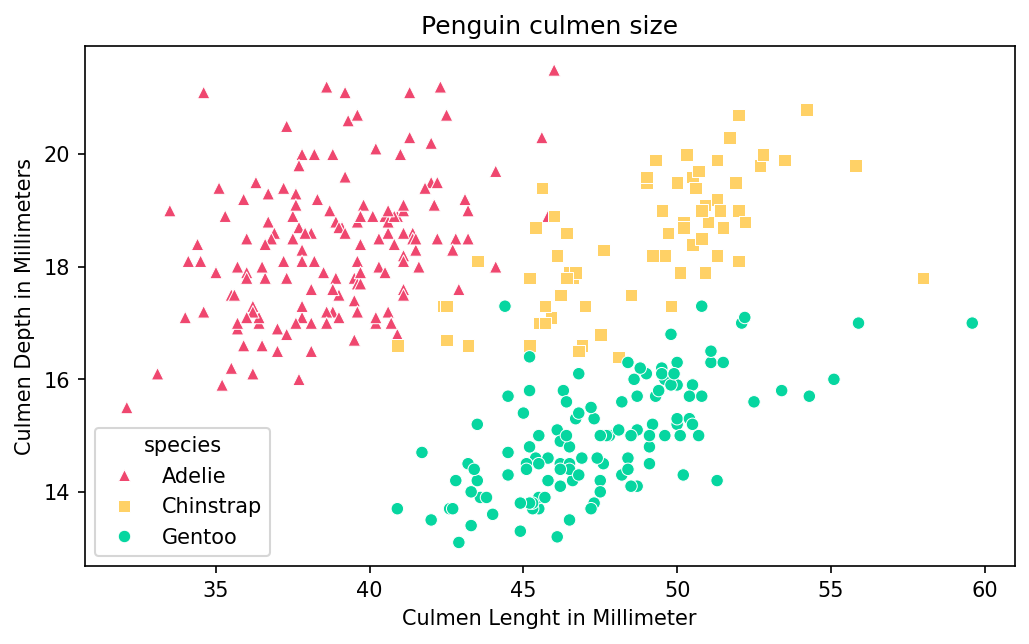

In [22]:
# Ploting a chart that displays penguins  "size" grouping by penguins species
# culmen_length_mm	culmen_depth_mm

plt.figure(figsize=(8, 4.5), dpi=150)

markers = {
    "Adelie": "^",
    "Chinstrap": "s",
    "Gentoo": "o"
}

sns.scatterplot(
    data=df,
    x="culmen_length_mm",
    y="culmen_depth_mm",
    hue="species",
    style="species",
    markers=markers,
    palette=palette
)

plt.title("Penguin culmen size")
plt.xlabel("Culmen Lenght in Millimeter")
plt.ylabel("Culmen Depth in Millimeters")
plt.show()

# INSIGHTS  

### Islands and Species  
Adelie penguins habits all three islands, but they are exclusive in torgersen island  
Biscoe Island is the main island for the Gentoo. Dream is the main island for the Chinstrap  
And Torgersen is the main island for the Adelie (Adelie is also the only species that appear in all 3 islands)  
Biscoe = Gentoo || Dream = Chinstrap || Torgersen = Adelie  

### Numerical values  
No possible outliers  
##### Gentoo  
Gentoo are massive in weight, having the biggest body mass. (137% of the mass of the other species)  
Gentoo have more sharp culmen and bigger flippers  
##### Adelie
Adelie penguins have less weight and smaller flippers  
Their culmen are the smallest among them all but their depht are a little bit above average  
##### Chinstrap  
Chinstrap are almost equal to the adelie species, but they have a bigger culmen (even bigger than the gentoo's ones)  
They also have a slighty bigger flipper comparing with the adelies, and a culmen of (aprox.) the same size  


# 🤖 Machine Learning Modeling

After understanding and preparing the dataset, machine learning techniques can be applied to predict penguin species based on their physical characteristics.

This section focuses on building a classification model capable of identifying whether a penguin belongs to the Adelie, Chinstrap, or Gentoo species.

# 🧪 Model Evaluation

Model evaluation is essential to measure how well the machine learning model performs on unseen data.

This section analyzes prediction accuracy and classification performance to understand the strengths and limitations of the trained model.

# 🧠 Final Insights & Conclusion

The final section summarizes the most important findings discovered throughout the analysis.

Here, the main biological patterns, statistical relationships, visualization insights, and machine learning results are consolidated to provide a complete overview of the project outcomes.